Data Preprocessing Using Split Data(Train,Test,Validation)

In [55]:
import pandas as pd
import numpy as np
import tensorflow as tf

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import matplotlib.pyplot as plt


Load The Datasets

In [56]:
train_data=pd.read_csv("../dataset/train_metadata.csv")

In [57]:
train_data.shape

(7009, 9)

In [58]:
val_data=pd.read_csv("../dataset/val_metadata.csv")

In [59]:
val_data.shape

(1503, 9)

In [60]:
test_data=pd.read_csv("../dataset/test_metadata.csv")

In [61]:
test_data.shape

(1503, 9)

In [62]:
train_data.isnull().sum()

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
image_path      0
label           0
dtype: int64

In [63]:
train_data.dtypes

lesion_id           str
image_id            str
dx                  str
dx_type             str
age             float64
sex                 str
localization        str
image_path          str
label             int64
dtype: object

In [ ]:
age_median = train_data['age'].median()

train_data['age']=train_data['age'].fillna(age_median)
val_data['age']=val_data['age'].fillna(age_median)
test_data['age']=test_data['age'].fillna(age_median)

In [65]:
train_data.isnull().sum()

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
image_path      0
label           0
dtype: int64

In [66]:
val_data.isnull().sum()

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
image_path      0
label           0
dtype: int64

In [67]:
test_data.isnull().sum()

lesion_id       0
image_id        0
dx              0
dx_type         0
age             0
sex             0
localization    0
image_path      0
label           0
dtype: int64

Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder
label_encoder=LabelEncoder()
train_data['label']=label_encoder.fit_transform(train_data['dx'])
val_data['label']=label_encoder.transform(val_data['dx'])
test_data['label']=label_encoder.transform(test_data['dx'])

In [69]:

label_encoder.classes_

array(['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc'], dtype=object)

In [ ]:
import cv2
import tensorflow as tf
IMG_SIZE = 224
def preprocess_image(image_path, label):
    def load_image(path):
        path = path.decode("utf-8")
        image = cv2.imread(path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
        image = image.astype("float32") / 255.0

        return image

    image=tf.numpy_function(load_image, [image_path],tf.float32)
    image.set_shape((IMG_SIZE, IMG_SIZE, 3))
    return image, label

In [ ]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2)

])

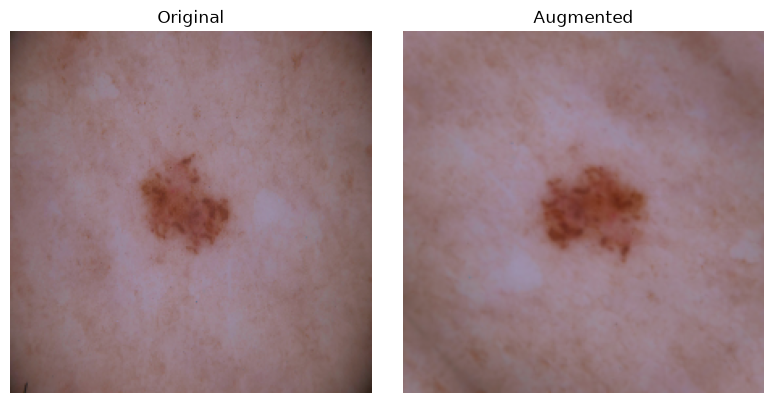

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread(train_data.iloc[0]["image_path"])
# Convert BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
# Resize image
img = cv2.resize(img, (224, 224))
# Normalize
img_array = img.astype("float32") / 255.0
# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)
# Apply augmentation
augmented = data_augmentation(img_array)
# Display images
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(img_array[0])
plt.title("Original")
plt.axis("off")
plt.subplot(1,2,2)
plt.imshow(augmented[0])
plt.title("Augmented")
plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
classes = np.unique(
train_data["label"]
)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_data["label"]
)
class_weights = dict(
    zip(classes, weights)
)


class_weights

{np.int64(0): np.float64(4.372426699937617),
 np.int64(1): np.float64(2.7813492063492062),
 np.int64(2): np.float64(1.3020620471855842),
 np.int64(3): np.float64(12.51607142857143),
 np.int64(4): np.float64(1.2853475151292866),
 np.int64(5): np.float64(0.2133572798392743),
 np.int64(6): np.float64(10.113997113997113)}

In [74]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_data["image_path"].values,
        train_data["label"].values
    )
)

train_dataset = train_dataset.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [ ]:
def apply_augmentation(image, label):

    image = tf.expand_dims(image, axis=0)

    image = data_augmentation(image)

    image = tf.squeeze(image, axis=0)

    return image, label

In [76]:
train_dataset = train_dataset.map(
    apply_augmentation,
    num_parallel_calls=tf.data.AUTOTUNE
)

In [ ]:
train_dataset = train_dataset.batch(32)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

In [ ]:
for images, labels in train_dataset.take(1):
    print(images.shape)
    print(labels.shape)

(32, 224, 224, 3)
(32,)


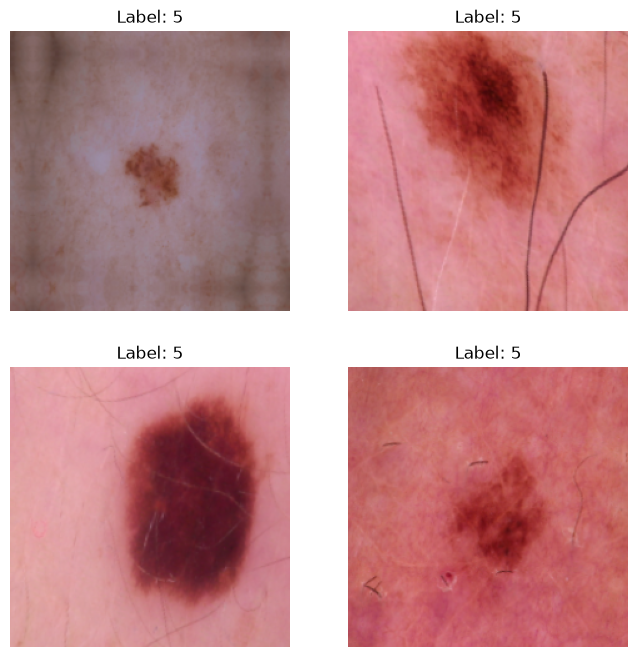

In [ ]:
import matplotlib.pyplot as plt

for images, labels in train_dataset.take(1):
    plt.figure(figsize=(8,8))
    for i in range(4):
        plt.subplot(2,2,i+1)
        plt.imshow(images[i])
        plt.title(f"Label: {labels[i].numpy()}")
        plt.axis("off")
    plt.show()

In [80]:
for images, labels in train_dataset.take(1):
    print(labels.numpy())

[5 5 5 5 5 5 5 5 5 5 5 4 5 5 5 5 4 5 5 4 5 5 4 1 5 5 0 5 5 5 5 5]


In [81]:
print("Train batches:", tf.data.experimental.cardinality(train_dataset))

Train batches: tf.Tensor(220, shape=(), dtype=int64)


In [82]:
val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_data["image_path"].values,
        val_data["label"].values
    )
)

val_dataset = val_dataset.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_dataset = val_dataset.batch(32)

val_dataset = val_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [83]:
print("Validation batches:", tf.data.experimental.cardinality(val_dataset))

Validation batches: tf.Tensor(47, shape=(), dtype=int64)


In [84]:
test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        test_data["image_path"].values,
        test_data["label"].values
    )
)

test_dataset = test_dataset.map(
    preprocess_image,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_dataset = test_dataset.batch(32)

test_dataset = test_dataset.prefetch(
    tf.data.AUTOTUNE
)

In [85]:
print("Test batches:", tf.data.experimental.cardinality(test_dataset))

Test batches: tf.Tensor(47, shape=(), dtype=int64)


In [86]:
import pickle

with open("../dataset/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

In [87]:
train_data.to_csv("../dataset/train_metadata.csv", index=False)
val_data.to_csv("../dataset/val_metadata.csv", index=False)
test_data.to_csv("../dataset/test_metadata.csv", index=False)